# Data Understanding & Cleaning

## About this notebook
This notebook loads the raw Online Retail dataset (UCI / Kaggle) and prepares it
for RFM analysis. The dataset contains transaction-level records from a UK-based
online retailer between **December 2010 and December 2011**.

Steps covered:
1. Load and inspect the raw data
2. Handle missing CustomerIDs
3. Remove cancelled transactions
4. Remove invalid quantities and prices
5. Convert dates and create a Revenue column
6. Save the cleaned dataset for the next notebook

In [169]:
import pandas as pd
import numpy as np 
import os

In [170]:
df=pd.read_csv("../data/online_retail.csv")

In [171]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom


In [172]:
df.describe()

,Quantity,UnitPrice,CustomerID
count,541909.000000,541909.000000,406829.000000
mean,9.552250,4.611114,15287.690570
std,218.081158,96.759853,1713.600303
min,-80995.000000,-11062.060000,12346.000000
25%,1.000000,1.250000,13953.000000
50%,3.000000,2.080000,15152.000000
75%,10.000000,4.130000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [173]:
df.shape

(541909, 8)

In [174]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [175]:
df.columns

Index(['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate',
       'UnitPrice', 'CustomerID', 'Country'],
      dtype='object')

Each row in the dataset represents a single product purchased as part of an invoice. A single invoice may contain multiple rows if multiple products are bought together.

In [176]:
df.isnull().sum() #see which columns have null values and the sum of all the null values in that column

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

CustomerID has null values so it indicates that there are transactions where customer data is not recorded

In [177]:
#check if there are duplicate rows/entries
df.duplicated().sum()

np.int64(5268)

In [178]:
df[df.duplicated()]

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,2010-12-01 11:45:00,1.25,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,2010-12-01 11:45:00,2.10,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,2010-12-01 11:45:00,2.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,2010-12-01 11:45:00,4.95,17908.0,United Kingdom
555,536412,22327,ROUND SNACK BOXES SET OF 4 SKULLS,1,2010-12-01 11:49:00,2.95,17920.0,United Kingdom
...,...,...,...,...,...,...,...,...
541675,581538,22068,BLACK PIRATE TREASURE CHEST,1,2011-12-09 11:34:00,0.39,14446.0,United Kingdom
541689,581538,23318,BOX OF 6 MINI VINTAGE CRACKERS,1,2011-12-09 11:34:00,2.49,14446.0,United Kingdom
541692,581538,22992,REVOLVER WOODEN RULER,1,2011-12-09 11:34:00,1.95,14446.0,United Kingdom
541699,581538,22694,WICKER STAR,1,2011-12-09 11:34:00,2.10,14446.0,United Kingdom


In [179]:
# check unique customers
df['CustomerID'].nunique()

4372

In [180]:
df['InvoiceNo'].nunique()

25900

This dataset contains 4372 unique customers and 25900 unique invoices


In [181]:
# sanity check for quantity 
df['Quantity'].describe()


count    541909.000000
mean          9.552250
std         218.081158
min      -80995.000000
25%           1.000000
50%           3.000000
75%          10.000000
max       80995.000000
Name: Quantity, dtype: float64

In [182]:
# sanity check for price
df['UnitPrice'].describe()

count    541909.000000
mean          4.611114
std          96.759853
min      -11062.060000
25%           1.250000
50%           2.080000
75%           4.130000
max       38970.000000
Name: UnitPrice, dtype: float64

# Handling Missing CustomerID

In [183]:
# number of rows having missing CustomerID
df['CustomerID'].isnull().sum()

np.int64(135080)

In [184]:
# Affecting percentage
df['CustomerID'].isnull().mean()*100

np.float64(24.926694334288598)

In [185]:
#remove rows with missing CustomerID
df=df.dropna(subset=['CustomerID'])

In [186]:
#confirming the removal
df['CustomerID'].isnull().sum()

np.int64(0)

In [187]:
#Convert customerid to integer as it represents an id not a float
df['CustomerID']=df['CustomerID'].astype(int)


**Removing Cancelled Transactions**
- cancelled invoices represent returned or refunded purchases
- if we keep these cancelled transactions, revenue calculations and RFM will be wrong
- only keep completed purchases


In [188]:
# check how many cancelled invoices exist (Cancelled invoices start with C)
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(8905)

In [189]:
# remove the cancelled invoices
df=df[~df['InvoiceNo'].astype(str).str.startswith('C')]

In [190]:
#confirm the removal
df['InvoiceNo'].astype(str).str.startswith('C').sum()

np.int64(0)

Removing invalid quantity and price values


In [191]:
# check for invalid quantities
(df['Quantity']<=0).sum()

np.int64(0)

In [192]:
#checking for invalid prices
(df['UnitPrice']<=0).sum()

np.int64(40)

In [193]:
#Removing the invalid rows
df=df[(df['Quantity']>0) & (df['UnitPrice']>0)]


In [194]:
(df['Quantity']<=0).sum() #confirming the removal of invalid quantities
(df['UnitPrice']<=0).sum() #confirming the removal of invalid prices

np.int64(0)

Convert Date and Create Revenue Column

In [195]:
#convert InvoiceDate to datetime
df['InvoiceDate']=pd.to_datetime(df['InvoiceDate'])

In [196]:
df['InvoiceDate'].dtype

dtype('<M8[ns]')

In [197]:
#create revenue column
df['Revenue']=df['Quantity']*df['UnitPrice']

In [198]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 397884 entries, 0 to 541908
Data columns (total 9 columns):
 #   Column       Non-Null Count   Dtype         
---  ------       --------------   -----         
 0   InvoiceNo    397884 non-null  object        
 1   StockCode    397884 non-null  object        
 2   Description  397884 non-null  object        
 3   Quantity     397884 non-null  int64         
 4   InvoiceDate  397884 non-null  datetime64[ns]
 5   UnitPrice    397884 non-null  float64       
 6   CustomerID   397884 non-null  int64         
 7   Country      397884 non-null  object        
 8   Revenue      397884 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(2), object(4)
memory usage: 30.4+ MB


In [199]:
df[['Quantity','UnitPrice','Revenue']].head()

,Quantity,UnitPrice,Revenue
0,6,2.55,15.30
1,6,3.39,20.34
2,8,2.75,22.00
3,6,3.39,20.34
4,6,3.39,20.34


## Exploratory Data Analysis (EDA)

Before cleaning, we explore the data to understand its shape, date range,
geographic distribution, and top products. This helps us make informed
decisions during cleaning.

In [200]:
# Date range of the data
df['InvoiceDate'] = pd.to_datetime(df['InvoiceDate'])

print("Date Range:")
print(f"  From : {df['InvoiceDate'].min().date()}")
print(f"  To   : {df['InvoiceDate'].max().date()}")
print(f"  Span : {(df['InvoiceDate'].max() - df['InvoiceDate'].min()).days} days")

Date Range:
  From : 2010-12-01
  To   : 2011-12-09
  Span : 373 days


In [201]:
# Top 10 countries by number of transactions
print("Top 10 Countries by Transactions:")
print(df['Country'].value_counts().head(10))

Top 10 Countries by Transactions:
Country
United Kingdom    354321
Germany             9040
France              8341
EIRE                7236
Spain               2484
Netherlands         2359
Belgium             2031
Switzerland         1841
Portugal            1462
Australia           1182
Name: count, dtype: int64


In [202]:
#Top 10 products by revenue
df['Revenue'] = df['Quantity'] * df['UnitPrice']

top_products = (
    df.groupby('Description')['Revenue']
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

print("Top 10 Products by Revenue:")
print(top_products)

Top 10 Products by Revenue:
Description
PAPER CRAFT , LITTLE BIRDIE           168469.60
REGENCY CAKESTAND 3 TIER              142592.95
WHITE HANGING HEART T-LIGHT HOLDER    100448.15
JUMBO BAG RED RETROSPOT                85220.78
MEDIUM CERAMIC TOP STORAGE JAR         81416.73
POSTAGE                                77803.96
PARTY BUNTING                          68844.33
ASSORTED COLOUR BIRD ORNAMENT          56580.34
Manual                                 53779.93
RABBIT NIGHT LIGHT                     51346.20
Name: Revenue, dtype: float64


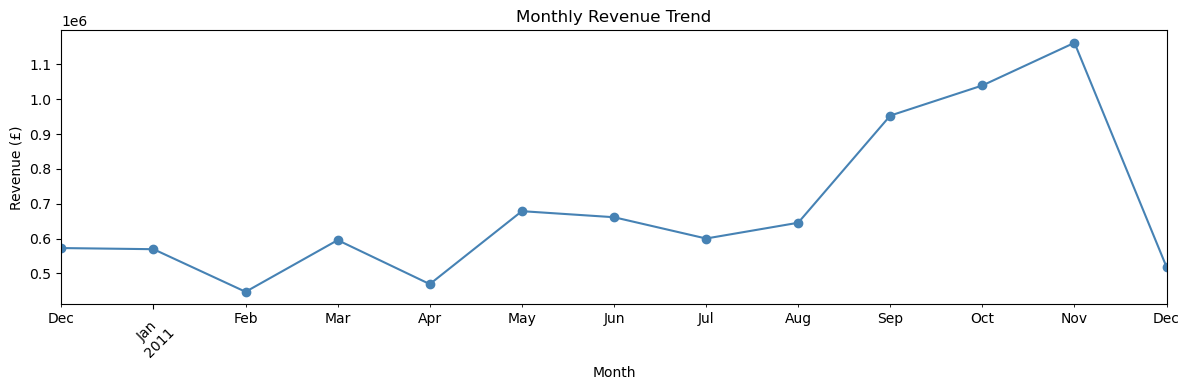

In [203]:
#Monthly revenue trend
import matplotlib.pyplot as plt

df['YearMonth'] = df['InvoiceDate'].dt.to_period('M')

monthly_revenue = df.groupby('YearMonth')['Revenue'].sum()

plt.figure(figsize=(12, 4))
monthly_revenue.plot(kind='line', marker='o', color='steelblue')
plt.title('Monthly Revenue Trend')
plt.xlabel('Month')
plt.ylabel('Revenue (£)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

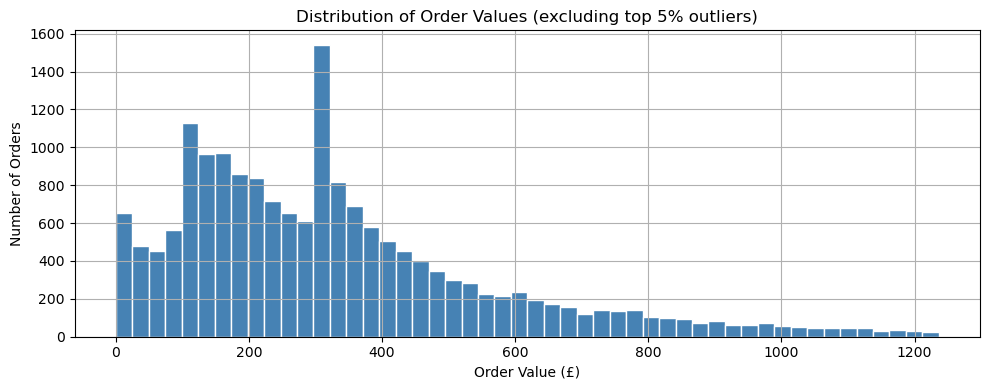


Average Order Value : £480.87
Median Order Value  : £303.04
Max Order Value     : £168469.60


In [204]:
# distribution of order values
order_totals = df.groupby('InvoiceNo')['Revenue'].sum()

plt.figure(figsize=(10, 4))
order_totals[order_totals < order_totals.quantile(0.95)].hist(bins=50, color='steelblue', edgecolor='white')
plt.title('Distribution of Order Values (excluding top 5% outliers)')
plt.xlabel('Order Value (£)')
plt.ylabel('Number of Orders')
plt.tight_layout()
plt.show()

print(f"\nAverage Order Value : £{order_totals.mean():.2f}")
print(f"Median Order Value  : £{order_totals.median():.2f}")
print(f"Max Order Value     : £{order_totals.max():.2f}")

In [205]:
df.to_csv("../data/online_retail_cleaned.csv", index=False)